In [1]:
import csv
import os
import pandas as pd
import numpy as np
from emmaemb.core import Emma
from emmaemb.vizualisation import (
    plot_emb_space,
    plot_knn_alignment_scores_across_k_and_distance_metrics,
    plot_pairwise_distance_comparison
)

IMG_OUTPUT_PATH = '/home/unix/vkrhk/EmmaEmb/img'
DATA_PATH = '/home/unix/vkrhk/EmmaEmb/data'
EMBEDDINGS_PATH = '/media/drive2/vkrhk/embeddings'
# [embeddings1_name, embeddings1_path] = "ESM2", f"{EMBEDDINGS_PATH}/esm2_t33_650M_UR50D/layer_33/chopped_1022_overlap_300"
# [embeddings2_name, embeddings2_path] = "ANKH", f"{EMBEDDINGS_PATH}/ankh_base/layer_None/chopped_1022_overlap_300"
# [embeddings1_name, embeddings1_path] = "ProstT5", f"{EMBEDDINGS_PATH}/Rostlab/ProstT5/layer_None/chopped_1022_overlap_300/"
# [embeddings2_name, embeddings2_path] = "ProtT5", f"{EMBEDDINGS_PATH}/Rostlab/prot_t5_xl_uniref50/layer_None/chopped_1022_overlap_300"
[embeddings1_name, embeddings1_path] = "ESM1", f"{EMBEDDINGS_PATH}/esm1_t34_670M_UR100/layer_34/chopped_1022_overlap_300/"
[embeddings2_name, embeddings2_path] = "ESMC", f"{EMBEDDINGS_PATH}/esmc-300m-2024-12/layer_None/chopped_1022_overlap_300/"

# colect data:
feature_data = []
embeddings1 = []
embeddings2 = []
concatenated_embeddings1_path = f"{DATA_PATH}/concatenated-embeddings/{embeddings1_name}_binding_site_embeddings.npy"
concatenated_embeddings2_path = f"{DATA_PATH}/concatenated-embeddings/{embeddings2_name}_binding_site_embeddings.npy"


with open(f'{DATA_PATH}/train.txt', 'r') as f:
    reader = csv.reader(f, delimiter=';')
    for ii, row in enumerate(reader):
        protein_id = row[0] + row[1]
        annotation = row[3].split(' ')
        annotation = [int(i[1:]) for i in annotation]
        sequence = row[4]
        path1 = f"{embeddings1_path}/{protein_id}.npy"
        path2 = f"{embeddings2_path}/{protein_id}.npy"

        if not (os.path.exists(path1) and os.path.exists(path2)):
            continue
        
        embedding1 = np.load(path1)
        embedding2 = np.load(path2)
        
        for i in range(len(sequence)):
            feature_data.append([sequence[i], 'BINDING' if i in annotation else 'NON-BINDING'])
        embeddings1.append(embedding1)
        embeddings2.append(embedding2)
        if ii > 100:
            break
# save embedding spaces to single .npy files
embeddings1 = np.concatenate(embeddings1, axis=0)
embeddings2 =  np.concatenate(embeddings2, axis=0)
np.save(concatenated_embeddings1_path, embeddings1)
np.save(concatenated_embeddings2_path, embeddings2)  

feature_data = pd.DataFrame.from_records(feature_data, columns=["amino acid", "binding_site"])

# initiate Emma object and load embedding spaces
emma = Emma(feature_data=feature_data)
emma.add_emb_space(
    embeddings_source=concatenated_embeddings1_path,
    emb_space_name=embeddings1_name)
emma.add_emb_space(
    embeddings_source=concatenated_embeddings2_path,
    emb_space_name=embeddings2_name)

30537 samples loaded.
Categories in meta data: ['binding_site']
Numerical columns in meta data: []
Embedding space 'ESM1' added successfully.
Embeddings have 1280 features each.
Embedding space 'ESMC' added successfully.
Embeddings have 960 features each.


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

for embeddings_name in [embeddings1_name, embeddings2_name]:
    emb_space = embeddings_name
    method = "PCA"
    embeddings = emma.emb[emb_space]["emb"]
    n_components = 15

    pca = PCA(n_components=n_components)
    embeddings_2d = pca.fit_transform(embeddings)
    variance_explained = pca.explained_variance_ratio_


    fig, axes = plt.subplots(n_components, n_components, figsize=(50, 50))
    for i in range(n_components):
        for ii in range(n_components):
            ax = axes[i, ii]
            scatter = ax.scatter(
                embeddings_2d[:, i],
                embeddings_2d[:, ii],
                c=emma.metadata["binding_site"].astype('category').cat.codes if emma._check_column_is_categorical("binding_site") else emma.metadata["binding_site"],
                cmap='viridis',
                alpha=0.5,
                s=3
            )
            if i == 0:
                ax.set_title(f"PC{ii + 1}")
            if ii == 0:
                ax.set_ylabel(f"PC{i + 1}")
            if i == n_components - 1:
                ax.set_xlabel(f"PC{ii + 1}")
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(f'img/{emb_space}_{method}_{n_components}.png')
    plt.close()

In [2]:
from scipy.stats import gaussian_kde
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def prepare_data(emma, embedding_space):
    embeddings = emma.emb[embedding_space]["emb"]
    labels = emma.metadata["binding_site"].apply(lambda x: 1 if x == 'BINDING' else 0).values
    return embeddings, labels

def run_PCA(n_components, embeddings):
    pca = PCA(n_components=n_components)
    embeddings = pca.fit_transform(embeddings)
    variance_explained = pca.explained_variance_ratio_
    return embeddings, variance_explained


def plot_kde(ax, x, y, cmap, label):
    # Calculate the point density
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    # Create grid
    xmin, xmax = x.min() - 1, x.max() + 1
    ymin, ymax = y.min() - 1, y.max() + 1
    xi, yi = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    zi = kde(np.vstack([xi.flatten(), yi.flatten()]))
    
    # Plot contours
    ax.contour(xi, yi, zi.reshape(xi.shape), colors=cmap, linewidths=1.5, alpha=0.8)
    # Add a representative legend entry
    ax.plot([], [], color=cmap, label=label)

def get_silhouette_score(embeddings, labels):
    score = silhouette_score(embeddings, labels)
    return score

def plot_scatter(embeddings, labels, x_idx, y_idx, emb_space, method, path=None):
    pc_x = embeddings[:, x_idx]
    pc_y = embeddings[:, y_idx]
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot non-binding (Class 0) in Blue
    plot_kde(ax, pc_x[labels == 0], pc_y[labels == 0], 'blue', 'Non-binding')

    # Plot binding (Class 1) in Red
    plot_kde(ax, pc_x[labels == 1], pc_y[labels == 1], 'red', 'Binding')

    # Add scatter points with low alpha to see individual residues
    ax.scatter(pc_x[labels == 0], pc_y[labels == 0], color='blue', s=5, alpha=0.1)
    ax.scatter(pc_x[labels == 1], pc_y[labels == 1], color='red', s=5, alpha=0.1)


    ax.set_xlim(pc_x.min() - 0.2, pc_x.max() + 0.2)
    ax.set_ylim(pc_y.min() - 0.2, pc_y.max() + 0.2)
    ax.set_xlabel(f'PC{x_idx + 1}')
    ax.set_ylabel(f'PC{y_idx + 1}')
    ax.set_title(f'KDE Comparing Binding vs Non-binding Residues\nSilhouette Score: {get_silhouette_score(embeddings[:, [x_idx, y_idx]], labels):.4f}\n{emb_space} - {method}')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    if path:
        plt.savefig(path)
    plt.show()

# First only two components:

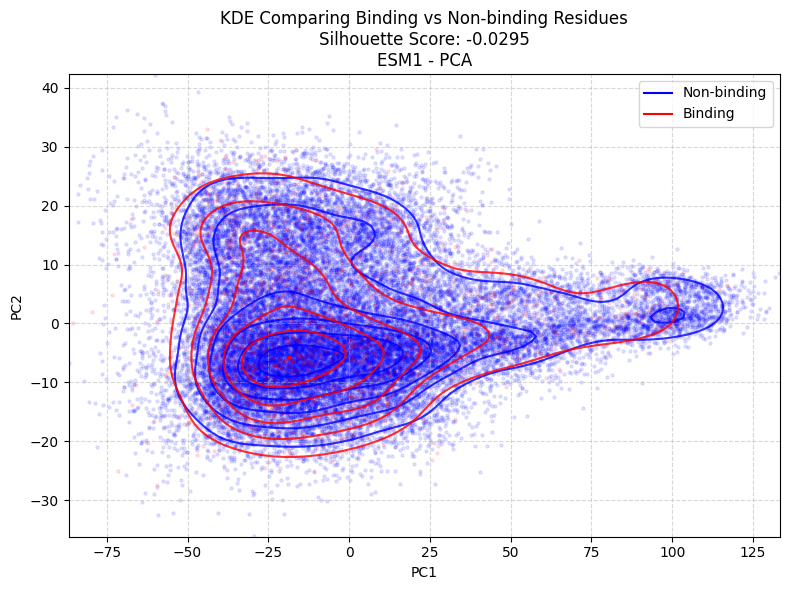

In [5]:
# run for 2 components 
embeddings_name = embeddings1_name
embeddings, labels = prepare_data(emma, embeddings_name)
embeddings, variance_explained = run_PCA(n_components=2, embeddings=embeddings)
plot_scatter(embeddings, labels, x_idx=0, y_idx=1, emb_space=embeddings_name, method="PCA", path=f'{IMG_OUTPUT_PATH}/PCA,n_components=2/{embeddings_name}_PCA_2_components.png')


# 15 components
Compute silhouette score, pick best the PC pair

Evaluating PC pair: (0, 1)
Evaluating PC pair: (0, 2)
Evaluating PC pair: (0, 3)
Evaluating PC pair: (0, 4)
Evaluating PC pair: (0, 5)
Evaluating PC pair: (0, 6)
Evaluating PC pair: (0, 7)
Evaluating PC pair: (0, 8)
Evaluating PC pair: (0, 9)
Evaluating PC pair: (0, 10)
Evaluating PC pair: (0, 11)
Evaluating PC pair: (0, 12)
Evaluating PC pair: (0, 13)
Evaluating PC pair: (0, 14)
Evaluating PC pair: (1, 2)
Evaluating PC pair: (1, 3)
Evaluating PC pair: (1, 4)
Evaluating PC pair: (1, 5)
Evaluating PC pair: (1, 6)
Evaluating PC pair: (1, 7)
Evaluating PC pair: (1, 8)
Evaluating PC pair: (1, 9)
Evaluating PC pair: (1, 10)
Evaluating PC pair: (1, 11)
Evaluating PC pair: (1, 12)
Evaluating PC pair: (1, 13)
Evaluating PC pair: (1, 14)
Evaluating PC pair: (2, 3)
Evaluating PC pair: (2, 4)
Evaluating PC pair: (2, 5)
Evaluating PC pair: (2, 6)
Evaluating PC pair: (2, 7)
Evaluating PC pair: (2, 8)
Evaluating PC pair: (2, 9)
Evaluating PC pair: (2, 10)
Evaluating PC pair: (2, 11)
Evaluating PC pa

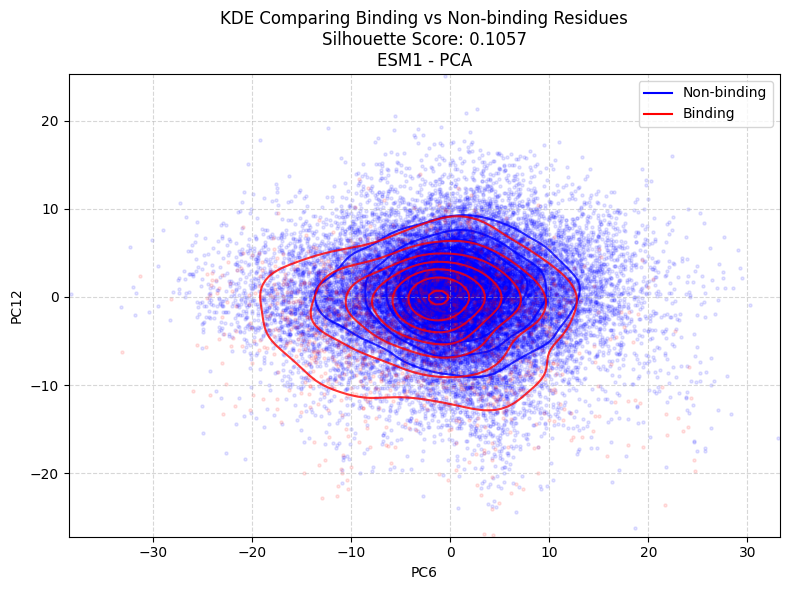

In [6]:
embeddings, labels = prepare_data(emma, embeddings_name)
embeddings, variance_explained = run_PCA(n_components=15, embeddings=embeddings)
best_idx = (0, 1)
best_score = -1
for i in range(15):
    for ii in range(i + 1, 15):
        print(f"Evaluating PC pair: ({i}, {ii})")
        score = get_silhouette_score(embeddings[:, [i, ii]], labels)
        if score > best_score:
            best_score = score
            best_idx = (i, ii)
print(f"Best PC pair: {best_idx} with Silhouette Score: {best_score:.4f}")
plot_scatter(embeddings, labels, x_idx=best_idx[0], y_idx=best_idx[1], emb_space=embeddings_name, method="PCA", path=f'{IMG_OUTPUT_PATH}/PCA,n_components=15,best/{embeddings_name}_PCA_best_pair.png')

Silhouette Score: 0.1748
Observed Centroid Distance: 2.0635
Permutation Test p-value: 0.0000


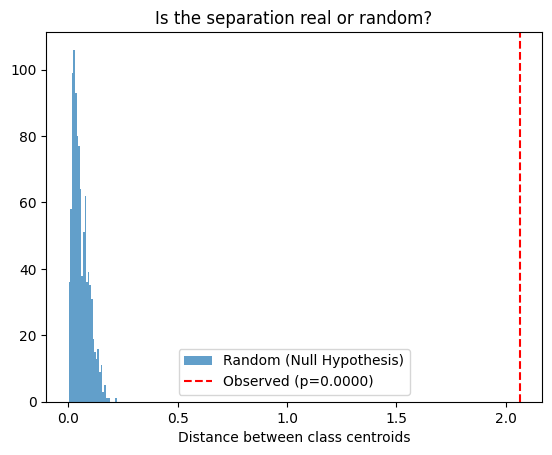

Silhouette Score: 0.0211
Observed Centroid Distance: 0.0950
Permutation Test p-value: 0.0000


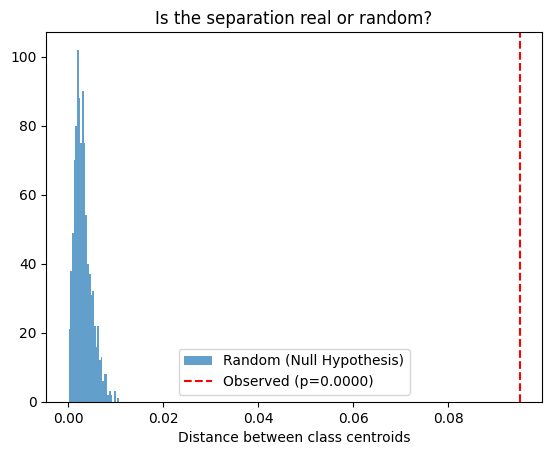

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
labels = emma.metadata["binding_site"].apply(lambda x: 1 if x == 'BINDING' else 0).values

for embeddings_name in [embeddings1_name, embeddings2_name]:
    emb_space = embeddings_name
    method = "PCA"
    embeddings = emma.emb[emb_space]["emb"]
    n_components = 15

    pca = PCA(n_components=n_components)
    embeddings_2d = pca.fit_transform(embeddings)
    variance_explained = pca.explained_variance_ratio_

    # take only PC 0 and 9
    embeddings_2d = embeddings_2d[:, [0, 9]]
    # --- 1. Silhouette Score ---
    # Measures how well each point fits in its own cluster vs the other
    # Ranges from -1 (bad) to +1 (perfect separation). 0 means total overlap.
    sil_score = silhouette_score(embeddings_2d, labels)
    print(f"Silhouette Score: {sil_score:.4f}")
    
    # --- 2. Permutation Test ---
    # We calculate the distance between the 'binding' and 'non-binding' centroids.
    # Then we shuffle the labels 1000 times to see how likely it is to get that distance by chance.
    
    def get_centroid_distance(data, labels):
        centroid_binding = data[labels == 1].mean(axis=0)
        centroid_nonbinding = data[labels == 0].mean(axis=0)
        return np.linalg.norm(centroid_binding - centroid_nonbinding)
    
    # Observed distance in your real data
    observed_dist = get_centroid_distance(embeddings_2d, labels)
    
    # Generate null distribution by shuffling labels
    n_permutations = 1000
    perm_distances = []
    for _ in range(n_permutations):
        shuffled_labels = shuffle(labels)
        perm_distances.append(get_centroid_distance(embeddings_2d, shuffled_labels))
    
    perm_distances = np.array(perm_distances)
    
    # Calculate p-value: what % of random shuffles yielded a distance >= ours?
    p_value = np.sum(perm_distances >= observed_dist) / n_permutations
    print(f"Observed Centroid Distance: {observed_dist:.4f}")
    print(f"Permutation Test p-value: {p_value:.4f}")
    
    # --- 3. Visualization of significance ---
    plt.hist(perm_distances, bins=30, alpha=0.7, label='Random (Null Hypothesis)')
    plt.axvline(observed_dist, color='red', linestyle='--', label=f'Observed (p={p_value:.4f})')
    plt.title('Is the separation real or random?')
    plt.xlabel('Distance between class centroids')
    plt.legend()
    plt.show()

KDE Plot generated: kde_pca_separation.png


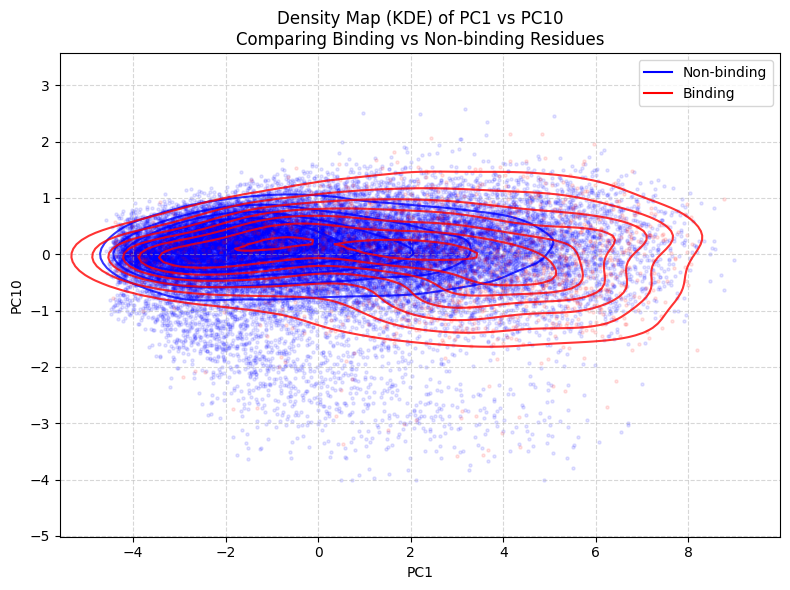

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

emb_space = embeddings1_name
method = "PCA"
embeddings = emma.emb[emb_space]["emb"]
n_components = 15
labels = emma.metadata["binding_site"].apply(lambda x: 1 if x == 'BINDING' else 0).values

pca = PCA(n_components=n_components)
embeddings_2d = pca.fit_transform(embeddings)
variance_explained = pca.explained_variance_ratio_

def plot_kde(ax, x, y, cmap, label):
    # Calculate the point density
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    # Create grid
    xmin, xmax = x.min() - 1, x.max() + 1
    ymin, ymax = y.min() - 1, y.max() + 1
    xi, yi = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    zi = kde(np.vstack([xi.flatten(), yi.flatten()]))
    
    # Plot contours
    ax.contour(xi, yi, zi.reshape(xi.shape), colors=cmap, linewidths=1.5, alpha=0.8)
    # Add a representative legend entry
    ax.plot([], [], color=cmap, label=label)

x_idx, y_idx = 0, 9
pc_x = embeddings_2d[:, 0]
pc_y = embeddings_2d[:, 9]

# Setup the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot non-binding (Class 0) in Blue
plot_kde(ax, pc_x[labels == 0], pc_y[labels == 0], 'blue', 'Non-binding')

# Plot binding (Class 1) in Red
plot_kde(ax, pc_x[labels == 1], pc_y[labels == 1], 'red', 'Binding')

# Add scatter points with low alpha to see individual residues
ax.scatter(pc_x[labels == 0], pc_y[labels == 0], color='blue', s=5, alpha=0.1)
ax.scatter(pc_x[labels == 1], pc_y[labels == 1], color='red', s=5, alpha=0.1)

ax.set_xlabel(f'PC{x_idx + 1}')
ax.set_ylabel(f'PC{y_idx + 1}')
ax.set_title(f'Density Map (KDE) of PC{x_idx + 1} vs PC{y_idx + 1}\nComparing Binding vs Non-binding Residues')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('kde_pca_separation.png')

print("KDE Plot generated: kde_pca_separation.png")

In [17]:
embeddings_2d.shape

(30537, 2)